# Unfold data

Wiener-SVD unfolding on **beam-quality data** vs **GENIE CCQE** MC (truth `mcnu`).

- **Data**: `evt_good` from `beam_data_1e20_qualitycut.df` (same as `data_mc_comparison.ipynb`)
- **MC**: `dfs_from_dir` on `sel_mup-wgts_genie_CCQE/merged_perTPC` (`dataset_locations.GENIE_GROUP_GLOBS`)
- **Systematics**: summed **`total_xsec`** block from `systematics-summary.ipynb` export (`CategorySummary/category_syst_summary.npz`; GENIE **xsec**, includes flat Exposure/Targets when exported with `include_flat=True`)


In [53]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [54]:
from os import path, makedirs
from datetime import datetime
from functools import partial
from pathlib import Path

import numpy as np
import pandas as pd

import sys
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana')
from pyanalib.split_df_helpers import load_dfs
from pyanalib.split_df_helpers_new import dfs_from_dir
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import save_fig_base_dir
from analysis_village.numucc_1p0pi.constants import *
from analysis_village.numucc_1p0pi.dataset_locations import PLOTS_BASE, GENIE_GROUP_GLOBS
from analysis_village.numucc_1p0pi.syst_disk_layout import category_summary_npz_path
from analysis_village.unfolding.wienersvd import *
from pyanalib.covariance import *

import matplotlib.pyplot as plt

import warnings
from pandas.errors import PerformanceWarning
warnings.filterwarnings("ignore", category=PerformanceWarning)
plt.style.use("presentation.mplstyle")


In [55]:
save_result = True
save_fig = save_result

today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(save_fig_base_dir, f"unfolding-data-{today_str}")
if save_result and not path.exists(save_fig_dir):
    makedirs(save_fig_dir)
UNFOLD_RESULTS_NPZ = path.join(save_fig_dir, "unfolding_results.npz")
print("saving plots in", save_fig_dir)
print("unfolding results:", UNFOLD_RESULTS_NPZ)

# --- paths (Spring Gen1 merged_perTPC) ---
DFS_ROOT = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs"
QUALITY_DF_DIR = path.join(DFS_ROOT, "2026_05_16_230705__sel_mup-data-1e20/merged_perTPC")
QUALITY_DF_PATH = path.join(QUALITY_DF_DIR, "beam_data_1e20_qualitycut.df")
DIR_GENIE_CCQE = path.dirname(GENIE_GROUP_GLOBS["CCQE"])  # .../merged_perTPC

KEYS2LOAD_MC = ["hdr", "evt", "mcnu"]
N_MAX_CONCAT = 999

# Category summary export from systematics-summary.ipynb (total_xsec for unfolding).
SYST_DISK_ROOT = "/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final"
CATEGORY_SUMMARY_OUT = (
    Path(PLOTS_BASE) / "syst_uncertainty_breakdown" / "final_selected" / "category_syst_summary.npz"
)
CATEGORY_SUMMARY_NPZ = category_summary_npz_path(SYST_DISK_ROOT)
if not path.isfile(CATEGORY_SUMMARY_NPZ) and CATEGORY_SUMMARY_OUT.is_file():
    CATEGORY_SUMMARY_NPZ = str(CATEGORY_SUMMARY_OUT)
UNFOLDING_SYST_KIND = "xsec"  # total_xsec (GENIE xsec)

print("quality-cut df:", QUALITY_DF_PATH)
print("GENIE CCQE dir:", DIR_GENIE_CCQE)
print("category summary:", CATEGORY_SUMMARY_NPZ, "exists =", path.isfile(CATEGORY_SUMMARY_NPZ))


saving plots in /exp/sbnd/data/users/munjung/plots/numucc1p0pi/unfolding-data-20260521
unfolding results: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/unfolding-data-20260521/unfolding_results.npz
quality-cut df: /pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230705__sel_mup-data-1e20/merged_perTPC/beam_data_1e20_qualitycut.df
GENIE CCQE dir: /pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_024530__sel_mup-wgts_genie_CCQE/merged_perTPC
category summary: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/CategorySummary/category_syst_summary.npz exists = True


In [56]:
from analysis_village.numucc_1p0pi.syst_category_summary import (
    TOTAL_XSEC,
    load_category_syst_summary,
)

if path.isfile(CATEGORY_SUMMARY_NPZ):
    _syst_summary = load_category_syst_summary(CATEGORY_SUMMARY_NPZ)
    _manifest = _syst_summary.get("manifest") or {}
    print("category summary schema:", _manifest.get("schema", "?"))
    print("flat terms [%]:", _manifest.get("flat_frac_unc_pct", {}))
    print("variables in NPZ:", len(_syst_summary["by_var"]))
else:
    print("WARNING: category summary missing — re-run export in systematics-summary.ipynb")
    _syst_summary = None


category summary schema: numucc_category_syst_summary_v1
flat terms [%]: {'pot': 2.0, 'ntargets': 1.0}
variables in NPZ: 18


## Load GENIE CCQE MC (`dfs_from_dir`)


In [57]:
genie_dfs = dfs_from_dir(
    DIR_GENIE_CCQE,
    filename_str="sel_mup-wgts_genie_CCQE",
    keys2load=KEYS2LOAD_MC,
    n_max_concat=N_MAX_CONCAT,
)
mc_evt_df = genie_dfs["evt"]
mc_hdr_df = genie_dfs["hdr"]
mc_nu_df = genie_dfs["mcnu"]
print(f"GENIE CCQE: evt={len(mc_evt_df):,}  hdr={len(mc_hdr_df):,}  mcnu={len(mc_nu_df):,}")


Found 19 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_024530__sel_mup-wgts_genie_CCQE/merged_perTPC/2026_05_11_024530__sel_mup-wgts_genie_CCQE_merged_0000.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_024530__sel_mup-wgts_genie_CCQE/merged_perTPC/2026_05_11_024530__sel_mup-wgts_genie_CCQE_merged_0002.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_024530__sel_mup-wgts_genie_CCQE/merged_perTPC/2026_05_11_024530__sel_mup-wgts_genie_CCQE_merged_0003.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_024530__sel_mup-wgts_genie_CCQE/merged_perTPC/2026_05_11_024530__sel_mup-wgts_genie_CCQE_merged_0004.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_024530__sel_mup-wgts_genie_CCQE/merged_perTPC/2026_05_11_024530__sel_mup-wgts_genie_CCQE_merged_0005.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_024530__sel_mup-wgts_genie_CCQE/merged_perTPC/2026_05

100%|██████████| 19/19 [02:47<00:00,  8.82s/it]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
GENIE CCQE: evt=70,535  hdr=6,061,666  mcnu=10,933,450


In [58]:
mc_hdr_df["pot"].sum()

np.float32(5.3465612e+20)

In [59]:
from pyanalib.variable_calculator import get_cc1p0pi_tki
from pyanalib.pandas_helpers import pad_column_name

def evt_df_fixed(df):
    slc_mudf = df.mu.pfp.trk
    slc_pdf = df.p.pfp.trk
    tki_reco = get_cc1p0pi_tki(
        slc_mudf,
        slc_pdf,
        pad_column_name(('P', 'p_muon'), slc_mudf),
        pad_column_name(('P', 'p_proton'), slc_pdf),
    )
    df['del_Tp_x'] = tki_reco['del_Tp_x']
    df['del_Tp_y'] = tki_reco['del_Tp_y']

    mc_mudf = df.mu.pfp.trk.truth.p
    mc_pdf = df.p.pfp.trk.truth.p
    tki_mc = get_cc1p0pi_tki(
        mc_mudf,
        mc_pdf,
        pad_column_name(('totp',), mc_mudf),
        pad_column_name(('totp',), mc_pdf),
    )
    df['mc_del_Tp_x'] = tki_mc['del_Tp_x']
    df['mc_del_Tp_y'] = tki_mc['del_Tp_y']
    df[('mc', 'del_Tp_x')] = tki_mc['del_Tp_x']
    df[('mc', 'del_Tp_y')] = tki_mc['del_Tp_y']

    n_before = len(df)
    df = df[np.abs(df.slc.vertex.x) > 10]
    if 'topo_categ' not in df.columns:
        df = df.copy()
        df.loc[:, 'topo_categ'] = get_topo_category(df)
    return df, n_before


mc_evt_df, n_evt_before_fv = evt_df_fixed(mc_evt_df)

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [60]:
len(mc_evt_df[mc_evt_df.topo_categ == 1]) / len(mc_nu_df[mc_nu_df.topo_categ == 1])

0.16607796627649152

## Load beam-quality-filtered data


In [61]:
quality_dfs = load_dfs(
    QUALITY_DF_PATH,
    keys2load=["hdr", "trigger", "evt_good"],
    n_max_concat=1,
)
data_evt_df = quality_dfs["evt_good"]
data_hdr_df = quality_dfs["hdr"].join(quality_dfs["trigger"])
data_evt_df[("mc", "iscc")] = 999
print(f"evt_good rows: {len(data_evt_df):,}")


evt_good rows: 12,804


In [62]:
data_tot_pot = data_hdr_df["pot"].sum() * 0.9822
data_gates = data_hdr_df.nbnbinfo.sum()
pot_str = get_pot_str(data_tot_pot)
pot_label = f"Events / Bin (POT={pot_str})"
data_evt_df["pot_weight"] = np.ones(len(data_evt_df))
print("data_tot_pot: %.3e" % data_tot_pot)
print("data tot gates : %.3e" % data_gates)


data_tot_pot: 8.808e+19
data tot gates : 1.953e+07


In [63]:
# mc_nu_df.columns = pd.MultiIndex.from_tuples(
    # [tuple(["mc"] + list(c)) for c in mc_nu_df.columns]
# )

mc_tot_pot = mc_hdr_df["pot"].sum()
mc_pot_scale = data_tot_pot / mc_tot_pot
print("mc_tot_pot: %.3e" % mc_tot_pot)
print("mc_pot_scale: %.3e" % mc_pot_scale)

mc_evt_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_evt_df))
mc_nu_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_nu_df))

if "topo_categ" not in mc_evt_df.columns:
    mc_evt_df.loc[:, "topo_categ"] = get_topo_category(mc_evt_df)
# mc_evt_df.loc[:, "genie_categ"] = get_genie_category(mc_evt_df)
if "topo_categ" not in mc_nu_df.columns:
    mc_nu_df.loc[:, "topo_categ"] = get_topo_category(mc_nu_df)
# mc_nu_df.loc[:, "genie_categ"] = get_genie_category(mc_nu_df)
# mc_evt_df.loc[mc_evt_df.mc.iscc.isna(), ("mc", "iscc")] = 999


mc_tot_pot: 5.347e+20
mc_pot_scale: 1.647e-01


In [64]:
# from pyanalib.variable_calculator import (
    # add_mc_cc1p0pi_tki_mcnu,
    # add_reco_cc1p0pi_tki_evtdf,
# )

# Reco TKI columns are ``del_*`` (matches VariableConfig.tki_* reco keys).
# data_evt_df = add_reco_cc1p0pi_tki_evtdf(data_evt_df)
# mc_evt_df = add_reco_cc1p0pi_tki_evtdf(mc_evt_df)
# mc_nu_df = add_mc_cc1p0pi_tki_mcnu(mc_nu_df)

In [65]:
# --- config for Wiener-SVD unfolding ---
C_type = 2
Norm_type = 0.

## TKI variables and per-TPC cut


In [66]:
# per-TPC FV cut

perTPC_inset = 10
def perTPC_cut(df):
    in_TPC1_cut = InFV(df.slc.vertex, det="SBND_TPC1", incathode=perTPC_inset) & InFV(df.mu.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset) & InFV(df.p.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset)
    in_TPC2_cut = InFV(df.slc.vertex, det="SBND_TPC2", incathode=perTPC_inset) & InFV(df.mu.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset) & InFV(df.p.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset)
    perTPC_cut = in_TPC1_cut | in_TPC2_cut
    return perTPC_cut

data_evt_df = data_evt_df[perTPC_cut(data_evt_df)]
mc_evt_df = mc_evt_df[perTPC_cut(mc_evt_df)]
# mc_nu_df = mc_nu_df[perTPC_cut(mc_nu_df)]
# intime_evt_df = intime_evt_df[perTPC_cut(intime_evt_df)]

In [67]:
from pyanalib.variable_calculator import get_cc1p0pi_tki
from pyanalib.pandas_helpers import pad_column_name

def evt_df_fixed(df):
    slc_mudf = df.mu.pfp.trk
    slc_pdf = df.p.pfp.trk
    tki_reco = get_cc1p0pi_tki(
        slc_mudf,
        slc_pdf,
        pad_column_name(('P', 'p_muon'), slc_mudf),
        pad_column_name(('P', 'p_proton'), slc_pdf),
    )
    df['del_Tp_x'] = tki_reco['del_Tp_x']
    df['del_Tp_y'] = tki_reco['del_Tp_y']

    mc_mudf = df.mu.pfp.trk.truth.p
    mc_pdf = df.p.pfp.trk.truth.p
    tki_mc = get_cc1p0pi_tki(
        mc_mudf,
        mc_pdf,
        pad_column_name(('totp',), mc_mudf),
        pad_column_name(('totp',), mc_pdf),
    )
    df['mc_del_Tp_x'] = tki_mc['del_Tp_x']
    df['mc_del_Tp_y'] = tki_mc['del_Tp_y']
    df[('mc', 'del_Tp_x')] = tki_mc['del_Tp_x']
    df[('mc', 'del_Tp_y')] = tki_mc['del_Tp_y']

    n_before = len(df)
    df = df[np.abs(df.slc.vertex.x) > 10]
    if 'topo_categ' not in df.columns:
        df = df.copy()
        df.loc[:, 'topo_categ'] = get_topo_category(df)
    return df, n_before


mc_evt_df, n_evt_before_fv = evt_df_fixed(mc_evt_df)
data_evt_df, n_evt_before_fv = evt_df_fixed(data_evt_df)
# intime_evt_df, n_evt_before_fv = evt_df_fixed(intime_evt_df)
# offbeam_evt_df, n_evt_before_fv = evt_df_fixed(offbeam_evt_df)

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Event rate → cross section conversion

Configure flux file, fiducial volume, and POT below. **V_SBND** matches the ray-traced **FV_split_truncY** geometry used for `Gen1.root` (see `analysis_village/flux/gsimple_raytrace.ipynb`): two anode slabs with **10 cm cathode inset** ($10<|x|<190$ cm) and **z-dependent** $|y|$ limits.


Fiducial volume (FV_split_truncY): $10<|x|<190$: $|y|<190$ ($10<z<250$), $-190<y<100$ ($250<z<450$)
Cathode inset: 10 cm
  slab 1: x=(-190.0, -10.0) cm, y=(-190.0, 190.0) cm, z=(10.0, 250.0) cm -> 1.6416e+07 cm³
  slab 2: x=(10.0, 190.0) cm, y=(-190.0, 190.0) cm, z=(10.0, 250.0) cm -> 1.6416e+07 cm³
  slab 3: x=(-190.0, -10.0) cm, y=(-190.0, 100.0) cm, z=(250.0, 450.0) cm -> 1.0440e+07 cm³
  slab 4: x=(10.0, 190.0) cm, y=(-190.0, 100.0) cm, z=(250.0, 450.0) cm -> 1.0440e+07 cm³
V_SBND = 5.371200e+07 cm³
Integrated flux: 1.518e-08
Integrated flux × POT = 1.336994e+12 ν/cm²
# argon target nuclei: 1.1203e+30
xsec_unit = 6.676589e-43 cm²/nucleon


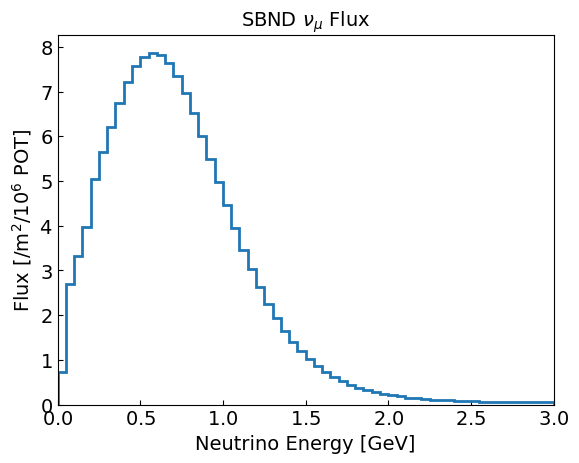

In [68]:
# --- rate → cross section conversion (configure here) ---
from analysis_village.flux.raytrace_volume_defs import (
    FV_SPLIT_TRUNCY_BOXES,
    RAYTRACE_VOLUME_LABEL,
)

FLUX_FILE = "/exp/sbnd/data/users/munjung/flux/SBND_gsimple_raytrace/Gen1.root"
FLUX_FV = "FV_split_truncY"  # geometry for Gen1.root (gsimple_raytrace.ipynb)
CATHODE_INSET_CM = 10  # exclude |x| < 10 cm at cathode gap
XSEC_TOT_POT = data_tot_pot  # beam POT used for exposure

# V_SBND: union of anode slabs (10 < |x| < 190), z-dependent |y|, 10 < z < 450 cm
print(f"Fiducial volume ({FLUX_FV}): {RAYTRACE_VOLUME_LABEL[FLUX_FV]}")
print(f"Cathode inset: {CATHODE_INSET_CM} cm")
V_SBND = 0.0
for i, box in enumerate(FV_SPLIT_TRUNCY_BOXES):
    dx = box["x_range"][1] - box["x_range"][0]
    dy = box["y_range"][1] - box["y_range"][0]
    dz = box["z_range"][1] - box["z_range"][0]
    v_box = dx * dy * dz
    V_SBND += v_box
    print(
        f"  slab {i + 1}: x={box['x_range']} cm, y={box['y_range']} cm, z={box['z_range']} cm"
        f" -> {v_box:.4e} cm³"
    )
print(f"V_SBND = {V_SBND:.6e} cm³")

# Plot νμ flux and print ∫Φ dE per cm² per POT
integrated_flux_per_pot = get_integrated_flux(FLUX_FILE, plot=True)
integrated_flux = integrated_flux_per_pot * XSEC_TOT_POT
print(f"Integrated flux × POT = {integrated_flux:.6e} ν/cm²")

N_TARGETS = (RHO * V_SBND / M_AR) * N_A
print(f"# argon target nuclei: {N_TARGETS:.4e}")

xsec_unit = 1.0 / (integrated_flux * N_TARGETS)
print(f"xsec_unit = {xsec_unit:.6e} cm²/nucleon")


In [69]:
var_configs = [
    # VariableConfig.all_events(),
            VariableConfig.muon_momentum(),
            VariableConfig.muon_direction(),
            VariableConfig.proton_momentum(),
            VariableConfig.proton_direction(),
            # VariableConfig.opening_angle(),
            VariableConfig.tki_del_alpha(),
            VariableConfig.tki_del_phi(),
            VariableConfig.tki_del_Tp(),
            VariableConfig.tki_del_p(),
            VariableConfig.tki_del_Tp_x(),
            VariableConfig.tki_del_Tp_y()
            ]

mc_evt_df.loc[mc_evt_df.mc.iscc.isna(), ("mc","iscc")] = 999
data_evt_df[("mc","iscc")] = 999

In [70]:
from pyanalib.variable_calculator import get_cc1p0pi_tki
from pyanalib.pandas_helpers import pad_column_name

def evt_df_fixed(df):
    slc_mudf = df.mu.pfp.trk
    slc_pdf = df.p.pfp.trk
    tki_reco = get_cc1p0pi_tki(
        slc_mudf,
        slc_pdf,
        pad_column_name(('P', 'p_muon'), slc_mudf),
        pad_column_name(('P', 'p_proton'), slc_pdf),
    )
    df['del_Tp_x'] = tki_reco['del_Tp_x']
    df['del_Tp_y'] = tki_reco['del_Tp_y']

    mc_mudf = df.mu.pfp.trk.truth.p
    mc_pdf = df.p.pfp.trk.truth.p
    tki_mc = get_cc1p0pi_tki(
        mc_mudf,
        mc_pdf,
        pad_column_name(('totp',), mc_mudf),
        pad_column_name(('totp',), mc_pdf),
    )
    df['mc_del_Tp_x'] = tki_mc['del_Tp_x']
    df['mc_del_Tp_y'] = tki_mc['del_Tp_y']
    df[('mc', 'del_Tp_x')] = tki_mc['del_Tp_x']
    df[('mc', 'del_Tp_y')] = tki_mc['del_Tp_y']

    n_before = len(df)
    df = df[np.abs(df.slc.vertex.x) > 10]
    if 'topo_categ' not in df.columns:
        df = df.copy()
        df.loc[:, 'topo_categ'] = get_topo_category(df)
    return df, n_before


mc_evt_df, n_evt_before_fv = evt_df_fixed(mc_evt_df)
data_evt_df, n_evt_before_fv = evt_df_fixed(data_evt_df)
# intime_evt_df, n_evt_before_fv = evt_df_fixed(intime_evt_df)
# offbeam_evt_df, n_evt_before_fv = evt_df_fixed(offbeam_evt_df)

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [71]:
eps = 1e-8
ratio = True
approval = "internal"
textloc = [0.05, 0.55]
ax_ylim_ratio = 1.6
breakdown_type = "topology"

unfolding_plotter = partial(
    overlay_hists,
    breakdown_type=breakdown_type,
    mc_df=mc_evt_df,
    data_df=data_evt_df,
    intime_df=None,
    ax_ylim_ratio=ax_ylim_ratio,
    ratio=ratio,
    textloc=textloc,
    approval=approval,
    save_fig=save_fig,
    syst_kind=UNFOLDING_SYST_KIND,
    syst_disk_root=SYST_DISK_ROOT,
    category_syst_summary_path=CATEGORY_SUMMARY_NPZ,
    load_syst_from_summary=True,
)

In [72]:

scale = 1.

In [73]:
# ======= systematic uncertainties (category_syst_summary export) ======
_CAT_SYST_LABELS = {
    "flux": "Flux",
    "g4": "G4",
    "mcstat": "MC stat.",
    "detector": "Detector",
    "cosmics": "Cosmics",
    "genie_rate": "GENIE (rate)",
    "genie_xsec": "GENIE (xsec)",
    "pot": "Exposure",
    "ntargets": "Targets",
}


def get_syst_unc(var_config, plot=False, save_fig=False, save_name=None):
    from analysis_village.numucc_1p0pi.syst_category_summary import (
        TOTAL_RATE,
        TOTAL_XSEC,
        load_category_syst_summary,
    )

    frac_uncert_total, frac_cov_matrix_total = get_category_summary_syst_unc(
        var_config,
        syst_kind=UNFOLDING_SYST_KIND,
        syst_disk_root=SYST_DISK_ROOT,
        category_syst_summary_path=CATEGORY_SUMMARY_NPZ,
    )
    total_key = TOTAL_XSEC if UNFOLDING_SYST_KIND == "xsec" else TOTAL_RATE

    if plot:
        summary = load_category_syst_summary(CATEGORY_SUMMARY_NPZ)
        pack = summary["by_var"][var_config.var_save_name]
        for cat_key, cat_blk in pack["categories"].items():
            w = np.asarray(cat_blk["frac_unc_pct"], dtype=float) / 100.0
            label = _CAT_SYST_LABELS.get(cat_key, cat_key)
            plt.hist(
                var_config.bin_centers,
                bins=var_config.bins,
                weights=w,
                histtype="step",
                linewidth=2,
                label=label,
            )
        tot_w = np.asarray(pack[total_key]["frac_unc_pct"], dtype=float) / 100.0
        plt.hist(
            var_config.bin_centers,
            bins=var_config.bins,
            weights=tot_w,
            histtype="step",
            linewidth=2,
            color="k",
            label="Total Syst.",
        )

        n_data, _ = np.histogram(data_evt_df[var_config.var_evt_reco_col], bins=var_config.bins)
        n_data_err = np.sqrt(n_data * scale)
        data_stat_uncert = n_data_err / (n_data * scale)
        plt.hist(
            var_config.bin_centers,
            bins=var_config.bins,
            weights=data_stat_uncert,
            histtype="step",
            linewidth=2,
            label="Data stat.",
            linestyle="--",
            color="k",
        )

        plt.xlim(var_config.bins[0], var_config.bins[-1])
        plt.ylim(0, max(frac_uncert_total) * 1.4)
        plt.xlabel(var_config.var_labels[1])
        plt.ylabel("Fractional uncertainty")
        plt.legend(fontsize=11, ncol=3, loc="upper center")
        plt.grid(which="major", linestyle="-", linewidth=0.7, alpha=0.7)
        plt.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.5)
        plt.minorticks_on()
        if save_fig:
            plt.savefig(save_name + fig_ext, bbox_inches="tight", dpi=dpi)
        plt.show()

    return frac_uncert_total, frac_cov_matrix_total

TypeError: unsupported operand type(s) for +: 'NoneType' and 'str'

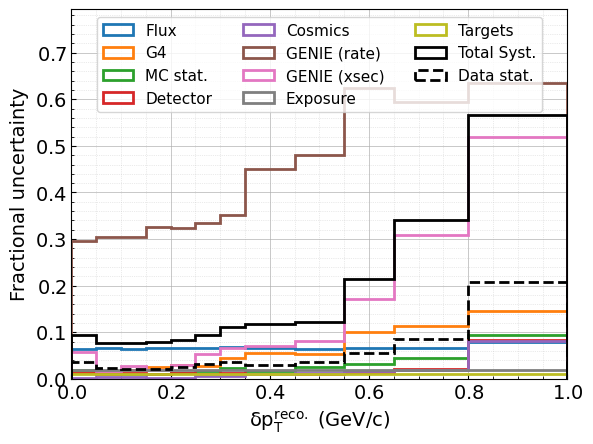

In [74]:
var_config = VariableConfig.tki_del_Tp()
syst_unc, syst_cov_matrix = get_syst_unc(var_config, plot=True, save_fig=True)

## GENIE unfolding and comparison

Wiener-SVD unfold beam-quality data using the **GENIE CCQE** response matrix, background-subtracted data spectrum, and category **total_xsec** systematic covariance. Produces reco-vs-true / response heatmaps, unfolded cross section vs **GENIE** truth model, writes **`unfolding_results.npz`** (data points, uncertainties, **`AddSmear`** / $A_c$), and caches unfold inputs for the optional GiBUU comparison below.


In [ ]:
def pack_unfold_results(unfold, var_config):
    """Bin-wise unfolded cross section, uncertainties, and AddSmear (A_c) for export."""
    bins = var_config.bins
    bin_widths = np.diff(bins)
    if len(bins) == 2:
        bin_widths = np.array([1.0])
    unfolded = np.asarray(unfold["unfold"], dtype=float)
    return {
        "bins": np.asarray(bins, dtype=float),
        "bin_centers": np.asarray(var_config.bin_centers, dtype=float),
        "bin_widths": bin_widths,
        "unfold": unfolded,
        "unfold_per_bin_width": unfolded / bin_widths,
        "stat_err": np.sqrt(np.maximum(np.diag(unfold["StatUnfoldCov"]), 0.0)),
        "syst_err": np.sqrt(np.maximum(np.diag(unfold["SystUnfoldCov"]), 0.0)),
        "total_err": np.sqrt(np.maximum(np.diag(unfold["UnfoldCov"]), 0.0)),
        "stat_err_per_bin_width": np.sqrt(np.maximum(np.diag(unfold["StatUnfoldCov"]), 0.0)) / bin_widths,
        "syst_err_per_bin_width": np.sqrt(np.maximum(np.diag(unfold["SystUnfoldCov"]), 0.0)) / bin_widths,
        "total_err_per_bin_width": np.sqrt(np.maximum(np.diag(unfold["UnfoldCov"]), 0.0)) / bin_widths,
        "AddSmear": np.asarray(unfold["AddSmear"], dtype=float),
        "UnfoldCov": np.asarray(unfold["UnfoldCov"], dtype=float),
        "StatUnfoldCov": np.asarray(unfold["StatUnfoldCov"], dtype=float),
        "SystUnfoldCov": np.asarray(unfold["SystUnfoldCov"], dtype=float),
    }


def mcnu_truth_xsec_model(mcnu_df, var_config, xsec_unit):
    """True signal cross-section model from weighted mcnu (POT scale from hdr × genweight)."""
    _vsn = var_config.var_save_name
    nudf_signal = signal_cut(mcnu_df[mcnu_df.topo_categ == 1])
    var_allmc, wgt_allmc = get_clipped_evts(
        nudf_signal, var_config.var_nu_col, var_config.bins, var_save_name=_vsn
    )
    nevts_allmc, _ = np.histogram(var_allmc, weights=wgt_allmc, bins=var_config.bins)
    return np.asarray(nevts_allmc, dtype=float) * xsec_unit

In [ ]:
unfold_cache = {}
unfold_results_by_var = {}

var_configs = [
    # VariableConfig.muon_momentum(),
    # VariableConfig.muon_direction_y(),
    # VariableConfig.proton_momentum(),
    # VariableConfig.proton_direction(),
    VariableConfig.tki_del_Tp(),
    # VariableConfig.tki_del_Tp_x(),
    # VariableConfig.tki_del_Tp_y(),
    # VariableConfig.tki_del_p(),
    # VariableConfig.tki_del_alpha(),
    # VariableConfig.tki_del_phi(),
]

for var_config in var_configs:

    # total_xsec fractional covariance from systematics-summary export
    syst_unc, syst_cov_matrix = get_syst_unc(var_config, plot=False, save_fig=False)

    plot_labels_hist = [var_config.var_labels[1], pot_label, ""]
    ret = unfolding_plotter(var_config=var_config,
                            plot_labels=plot_labels_hist,
                            syst=syst_cov_matrix,
                            save_name=path.join(save_fig_dir, "{}_{}".format(var_config.var_save_name, breakdown_type)))
                            
    tot_frac_cov = syst_cov_matrix + np.diag(1/ret["total_data"])
    tot_cov = cov_from_fraccov(tot_frac_cov, ret["total_mc"])
    ret_chi2 = get_chi2(ret["total_data"], ret["total_mc"], tot_cov)

    evtdf_signal = mc_evt_df[mc_evt_df.topo_categ == 1]
    nudf_signal = mc_nu_df[mc_nu_df.topo_categ == 1]
    ret_signal_hists = signal_hists(mc_evt_df, mc_nu_df, var_config, mode="unfold", return_data=True, plot=False)

    save_fig_name = "{}/{}-reco_vs_true".format(save_fig_dir, var_config.var_save_name)
    if len(var_config.bins) == 2:
        reco_vs_true = np.array([[1.0]])
    else:
        reco_vs_true, _, _ = np.histogram2d(ret_signal_hists["var_sel_truth"], 
                                            ret_signal_hists["var_sel_reco"], 
                                            weights=ret_signal_hists["wgt_sel_truth"],
                                            bins=var_config.bins)

    plot_heatmap(reco_vs_true, 
                var_config.bins, 
                plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "Smearing"],
                verbose=True,
                save_fig=save_fig, 
                save_name=save_fig_name)

    eff = ret_signal_hists["nevts_sel_truth"] / ret_signal_hists["nevts_allmc"]
    print(eff)

    save_fig_name = "{}/{}-response_matrix".format(save_fig_dir, var_config.var_save_name)
    response = get_response_matrix(reco_vs_true, eff)

    plot_heatmap(response, 
                var_config.bins, 
                plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "Response"],
                save_fig=save_fig, 
                verbose=True,
                cmap="viridis",
                save_name=save_fig_name)


    nevts_sel_data = ret["total_data"] - ret["total_mc_bkgd"] 
    measured = nevts_sel_data * xsec_unit  # bkgd-subtracted data
    model    = ret_signal_hists["nevts_allmc"] * xsec_unit
    Covariance = cov_from_fraccov(syst_cov_matrix, ret_signal_hists["nevts_sel_reco"]) * xsec_unit**2 
    unfold = WienerSVD(response, model, measured, Covariance*1.1, C_type, Norm_type, stat_scaling=xsec_unit)
    # print(unfold.keys())
    # decomp_cov = Matrix_Decomp(model, unfold['SystUnfoldCov'])

    models = {"GENIE": model} #,  "AR23": nevts_dict["GENIE AR23"]}
    save_name = f"{save_fig_dir}/{var_config.var_save_name}-unfolded_event_rates-DATA"

    # if measured: do not overwrite zeros with O(1) in xsec units — that destroys Poisson stats

    plot_unfolded_result(unfold, 
                        measured, 
                        models, 
                        var_config,
                        # chi2_list = [float(ret_chi2[0])],
                        xsec_unit=xsec_unit,
                        save_fig=save_fig, 
                        save_name=save_name,
                        data=True,
                        closure_test=False)

    unfold_cache[var_config.var_save_name] = {
        "unfold": unfold,
        "model": model,
        "measured": measured,
        "syst_cov_matrix": syst_cov_matrix,
    }
    unfold_results_by_var[var_config.var_save_name] = {
        **pack_unfold_results(unfold, var_config),
        "measured": np.asarray(measured, dtype=float),
        "model_genie": np.asarray(model, dtype=float),
        "xsec_unit": np.float64(xsec_unit),
    }

    save_fig_name = "{}/{}-{}-add_smear".format(save_fig_dir, var_config.var_save_name, "data")
    plot_heatmap(unfold["AddSmear"], 
                var_config.bins, 
                plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "$A_c$"],
                save_fig=save_fig, 
                save_name=save_fig_name)

if save_result and unfold_results_by_var:
    manifest = {
        "schema": "numucc1p0pi_unfolding_results_v1",
        "date": today_str,
        "quality_df": QUALITY_DF_PATH,
        "genie_dir": DIR_GENIE_CCQE,
        "data_tot_pot": float(data_tot_pot),
        "mc_tot_pot": float(mc_tot_pot),
        "xsec_unit": float(xsec_unit),
        "flux_file": FLUX_FILE,
        "flux_fv": FLUX_FV,
        "variables": list(unfold_results_by_var.keys()),
        "C_type": C_type,
        "Norm_type": Norm_type,
    }
    npz_payload = {
        "manifest": np.array([manifest], dtype=object),
        "xsec_unit": np.float64(xsec_unit),
        "data_tot_pot": np.float64(data_tot_pot),
    }
    for vn, pack in unfold_results_by_var.items():
        for key, val in pack.items():
            npz_payload[f"{vn}::{key}"] = val
    np.savez_compressed(UNFOLD_RESULTS_NPZ, **npz_payload)
    print("saved unfolding results:", UNFOLD_RESULTS_NPZ)


In [ ]:
save_fig_dir

## Load GiBUU MC

GiBUU **`mcnu`** is loaded for generator comparison only (no GiBUU unfolding). Weights are **`pot_weight = (data_tot_pot / gibuu_tot_pot) × genweight`**, with **`gibuu_tot_pot`** from **`hdr`**.

The comparison curve is **`nevts_allmc(mcnu) × xsec_unit`**, then folded with the **GENIE** Wiener **`AddSmear`** ($A_c$) from the data unfold — same detector smearing as GENIE MC truth.

Set `LOAD_GIBUU = True` and point `gibuu_df_dir` at your GiBUU dfs directory.


In [ ]:
# --- GiBUU MC (optional): hdr POT scale × genweight on mcnu only ---
LOAD_GIBUU = True  # set True when gibuu_df_dir is valid
gibuu_df_dir = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_18_104112__sel_mup-mc-GiBUU/merged_perTPC"
gibuu_mcnu_df = None
gibuu_pot_scale = None


if LOAD_GIBUU and gibuu_df_dir is not None:
    try:
        gibuu_dfs = dfs_from_dir(
            gibuu_df_dir,
            filename_str="sel_mup",
            keys2load=["hdr", "mcnu"],
            n_max_concat=N_MAX_CONCAT,
        )
        gibuu_hdr_df = gibuu_dfs["hdr"]
        gibuu_mcnu_df = gibuu_dfs["mcnu"]

        gibuu_tot_pot = gibuu_hdr_df["pot"].sum()
        gibuu_pot_scale = data_tot_pot / gibuu_tot_pot
        gw_nu = np.asarray(gibuu_mcnu_df["mc"]["genweight"], dtype=float)
        gibuu_mcnu_df["pot_weight"] = gibuu_pot_scale * gw_nu

        gibuu_mcnu_df.loc[gibuu_mcnu_df["mc"]["iscc"].isna(), ("mc", "iscc")] = 999
        gibuu_mcnu_df.loc[:, "topo_categ"] = get_topo_category(gibuu_mcnu_df)

        print(
            "GiBUU: loaded %d mcnu rows; gibuu_tot_pot=%.3e  gibuu_pot_scale=%.3e"
            % (len(gibuu_mcnu_df), gibuu_tot_pot, gibuu_pot_scale)
        )
    except Exception as e:
        gibuu_mcnu_df = None
        gibuu_pot_scale = None
        print("GiBUU load failed; comparison disabled:", e)
else:
    print("GiBUU comparison disabled (set LOAD_GIBUU True and gibuu_df_dir).")

## GiBUU generator comparison

Overlay unfolded **data** (GENIE-based Wiener unfold) with **GENIE** and **GiBUU** truth models folded by the same GENIE **`AddSmear`** ($A_c$). GiBUU uses **`mcnu_truth_xsec_model`** (no GiBUU response matrix or second unfold).


In [ ]:
for var_config in var_configs:
    if gibuu_mcnu_df is None:
        print("GiBUU comparison skipped (GiBUU MC not loaded).")
        break

    cache = unfold_cache[var_config.var_save_name]
    unfold = cache["unfold"]
    model = cache["model"]
    measured = cache["measured"]

    # GiBUU truth: weighted mcnu histogram × xsec_unit; fold with GENIE A_c (no GiBUU unfold).
    model_gibuu = mcnu_truth_xsec_model(gibuu_mcnu_df, var_config, xsec_unit)
    if save_result:
        unfold_results_by_var[var_config.var_save_name]["model_gibuu"] = np.asarray(
            model_gibuu, dtype=float
        )
        unfold_results_by_var[var_config.var_save_name]["model_gibuu_folded"] = (
            unfold["AddSmear"] @ model_gibuu
        )
    save_name_gibuu = f"{save_fig_dir}/{var_config.var_save_name}-unfolded_event_rates-DATA-GiBUU"
    plot_unfolded_result(
        unfold,
        measured,
        {"GiBUU": model_gibuu},
        var_config,
        xsec_unit=xsec_unit,
        save_fig=save_fig,
        save_name=save_name_gibuu,
        data=True,
        closure_test=False,
    )
    save_name_both = f"{save_fig_dir}/{var_config.var_save_name}-unfolded_event_rates-DATA-GENIE-GiBUU"
    plot_unfolded_result(
        unfold,
        measured,
        {"GENIE": model, "GiBUU": model_gibuu},
        var_config,
        xsec_unit=xsec_unit,
        save_fig=save_fig,
        save_name=save_name_both,
        data=True,
        closure_test=False,
    )

if save_result and gibuu_mcnu_df is not None and unfold_results_by_var:
    manifest = {
        "schema": "numucc1p0pi_unfolding_results_v1",
        "date": today_str,
        "quality_df": QUALITY_DF_PATH,
        "genie_dir": DIR_GENIE_CCQE,
        "gibuu_df_dir": gibuu_df_dir,
        "data_tot_pot": float(data_tot_pot),
        "mc_tot_pot": float(mc_tot_pot),
        "gibuu_pot_scale": float(gibuu_pot_scale),
        "xsec_unit": float(xsec_unit),
        "flux_file": FLUX_FILE,
        "flux_fv": FLUX_FV,
        "variables": list(unfold_results_by_var.keys()),
        "C_type": C_type,
        "Norm_type": Norm_type,
    }
    npz_payload = {
        "manifest": np.array([manifest], dtype=object),
        "xsec_unit": np.float64(xsec_unit),
        "data_tot_pot": np.float64(data_tot_pot),
    }
    for vn, pack in unfold_results_by_var.items():
        for key, val in pack.items():
            npz_payload[f"{vn}::{key}"] = val
    np.savez_compressed(UNFOLD_RESULTS_NPZ, **npz_payload)
    print("updated unfolding results (GiBUU models):", UNFOLD_RESULTS_NPZ)


In [ ]:
save_fig_dir

In [ ]:
save_fig

In [ ]:
data_gates